<a href="https://colab.research.google.com/github/toshikis/AISeminar/blob/%E5%BE%A9%E7%BF%92%E7%94%A8%E6%95%99%E6%9D%90/%E7%94%BB%E5%83%8F%E8%AA%8D%E8%AD%98%E2%91%A7%E4%BF%A1%E5%8F%B7%E6%A4%9C%E5%87%BA_%E8%AC%9B%E5%B8%AB%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=#0e89b2>0. ライブラリのインポート</font>

In [ ]:
!pip install japanize-matplotlib
!pip install icrawler
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 34.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=f0e5b00a7be0270486bd13557a424444571faf6ad48ea0fcad185151c1d05cfd
  Stored in directory: /root/.cache/pip/wheels/61/7a/6b/df1f79be9c59862525070e157e62b08eab8ece27c1b68fbb94
Successfully built japanize-matplotlib
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 872.3/872.3 kB 19.2 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

import cv2
from google.colab.patches import cv2_imshow
import zipfile
import os
import shutil
import xml.etree.ElementTree as ET
from PIL import Image

import keras
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

import tensorflow as tf

from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import decode_predictions, preprocess_input
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerat

from icrawler.builtin import BingImageCrawler
from ultralytics import YOLO

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# <font color=#0e89b2>1. 総合問題：赤信号と青信号の検出</font>

ここでは、画像から赤信号と青信号を区別して検出するモデルを作成します。<br>
言わずもがなこれは自動運転AIのコアとなるモデルの一つで、<br>
このAIエンジニア育成講座のトリとしてふさわしいテーマとなっております。<br>
<br>
YOLOv8では「信号（trrafic light）」というクラスが事前学習されていますが、<br>
赤信号と青信号は区別されていません。<br>
そこで今回のモデルの作成にあたっては、ファインチューニングが必要です。<br>
<br>
以下のようなステップで進めていきましょう。

## <font color=#0e89b2>ステップ1：スクレイピングによるデータの収集</font>

スクレイピングで、赤信号と青信号のデータを収集してください。<br>
なるべく多くのデータを収集しましょう。

## <font color=#0e89b2>ステップ2：アノテーション用データの作成</font>

ステップ1で収集したデータにタグ付けを行って、アノテーション用データを作成しましょう。<br>
なお、スクレイピング時には、意図したものではない画像も収集されてしまいます。<br>
これらはアノテーション時に取り除いておきましょう。

## <font color=#0e89b2>ステップ3：モデルの構築・学習・予測</font>

YOLOv8モデルをベースとして、ステップ2で用意したデータを使ってファインチューニングを行い、モデルを構築してください。<br>
そして出来上がったモデルを使用して、こちらの画像で予測を実行してください。
* https://drive.google.com/drive/folders/1DN2wVCzKNUDgKAucdv4F_OYTc0h3f7JB?usp=drive_link

注）
* 歩行者用信号と車両用信号は、区別してもしなくても構いません。
* 時間が限られている事もあり、十分な数のアノテーションデータを準備することは難しいので、精度はそこそこを目指しましょう。

# <font color=#0e89b2>2. 解答</font>

## <font color=#0e89b2>ステップ1：スクレイピングによるデータの収集</font>

Bing用クローラーを作成します。

In [ ]:
def image_crawler(crawler_model, target_directory, keyword):
  #Bing用クローラーの生成
  crawler = BingImageCrawler(
      storage={'root_dir': target_directory}) #ダウンロード先のディレクトリ名

  #クロール（キーワード検索による画像収集）の実行
  crawler.crawl(
      keyword=keyword, #検索キーワード
      max_num=1000 #ダウンロードする画像の最大枚数
      )

クローラーを使ってデータを収集します。<br>
なお精度を追求したい場合には、なるべく大量の学習データを準備できるに越したことはありません。<br>
そのような場合には、以下のように複数言語でクローリングを行うのも一つのテクニックです。<br>
<br>
今回は、日本語のみでクローリングを行うことにします。

In [ ]:
#赤信号
image_crawler(BingImageCrawler, '/content/images/red_light/japanese', "赤信号") #Bing×日本語
# image_crawler(BingImageCrawler, '/content/images/red_light/english', "red light traffic") #Bing×英語
# image_crawler(BingImageCrawler, '/content/images/red_light/spanish', "semáforo en rojo") #Bing×スペイン語
# image_crawler(BingImageCrawler, '/content/images/red_light/french', "feu rouge circulation") #Bing×フランス語
# image_crawler(BingImageCrawler, '/content/images/red_light/german', "rote Ampel") #Bing×ドイツ語
# image_crawler(BingImageCrawler, '/content/images/red_light/chinese', "红灯") #Bing×中国語
# image_crawler(BingImageCrawler, '/content/images/red_light/korean', "빨간불") #Bing×韓国語

#青信号
image_crawler(BingImageCrawler, '/content/images/blue_light/japanese', "青信号") #Bing×日本語
# image_crawler(BingImageCrawler, '/content/images/blue_light/english', "blue light traffic") #Bing×英語
# image_crawler(BingImageCrawler, '/content/images/blue_light/spanish', "semáforo en azul") #Bing×スペイン語
# image_crawler(BingImageCrawler, '/content/images/blue_light/french', "feu vert　circulationl") #Bing×フランス語
# image_crawler(BingImageCrawler, '/content/images/blue_light/german', "Grün Ampel") #Bing×ドイツ語
# image_crawler(BingImageCrawler, '/content/images/blue_light/chinese', "绿灯") #Bing×中国語
# image_crawler(BingImageCrawler, '/content/images/blue_light/korean', "초록불") #Bing×韓国語

ERROR:downloader:Exception caught when downloading file https://free-materials.com/adm/wp-content/uploads/2016/10/adtDSC_2839.jpg, error: HTTPSConnectionPool(host='free-materials.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://free-materials.com/adm/wp-content/uploads/2016/10/adtDSC_2839.jpg, error: HTTPSConnectionPool(host='free-materials.com', port=443): Read timed out. (read timeout=5), remaining retry times: 1
ERROR:downloader:Exception caught when downloading file https://free-materials.com/adm/wp-content/uploads/2016/10/adtDSC_2839.jpg, error: HTTPSConnectionPool(host='free-materials.com', port=443): Read timed out. (read timeout=5), remaining retry times: 0
ERROR:downloader:Exception caught when downloading file https://free-materials.com/adm/wp-content/uploads/2016/10/adtDSC_2839-750x499.jpg, error: HTTPSConnectionPool(host='free-materials.com', port=443): Read timed out. (read timeout=5

収集したデータを全て`/content/images/all`配下に集めてzipファイル化します。<br>
まずは、データを`/content/images/all`配下にコピーします。

In [ ]:
# コピー元のフォルダパス
src_folder = '/content/images'

# コピー先のフォルダパス
dst_folder = '/content/images/all'

# コピー先のフォルダが存在しない場合は作成
os.makedirs(dst_folder, exist_ok=True)

# 言語名のリスト
languages = ['japanese']
colors = ['blue_light', 'red_light']

# 各フォルダ内のファイルをコピー
for color in colors:
    for language in languages:
        folder_path = os.path.join("/content", "images", color, language)

        for filename in os.listdir(folder_path):
            src_path = os.path.join(folder_path, filename)

            # 新しいファイル名を作成
            file_name, file_ext = os.path.splitext(filename)
            new_file_name = f"{color}_{language}_{file_name}.jpg"

            dst_path = os.path.join(dst_folder, new_file_name)
            shutil.copy(src_path, dst_path)

print("ファイルのコピーが完了しました。")

ファイルのコピーが完了しました。


`/content/images/all`のフォルダをzipファイル化します。

In [ ]:
#元のフォルダ名
folder_name = "/content/images/all"

#作成するZIPファイルの名前
zip_name = "traffic_light"

#フォルダをZIPファイルにアーカイブ
shutil.make_archive(zip_name, "zip", folder_name)

'/content/traffic_light.zip'

このzipファイルをダウンロードして、ローカルでアノテーション作業を行いましょう。

## <font color=#0e89b2>ステップ2：アノテーション用データの作成</font>

VoTTでアノテーション作業を行っていきます。

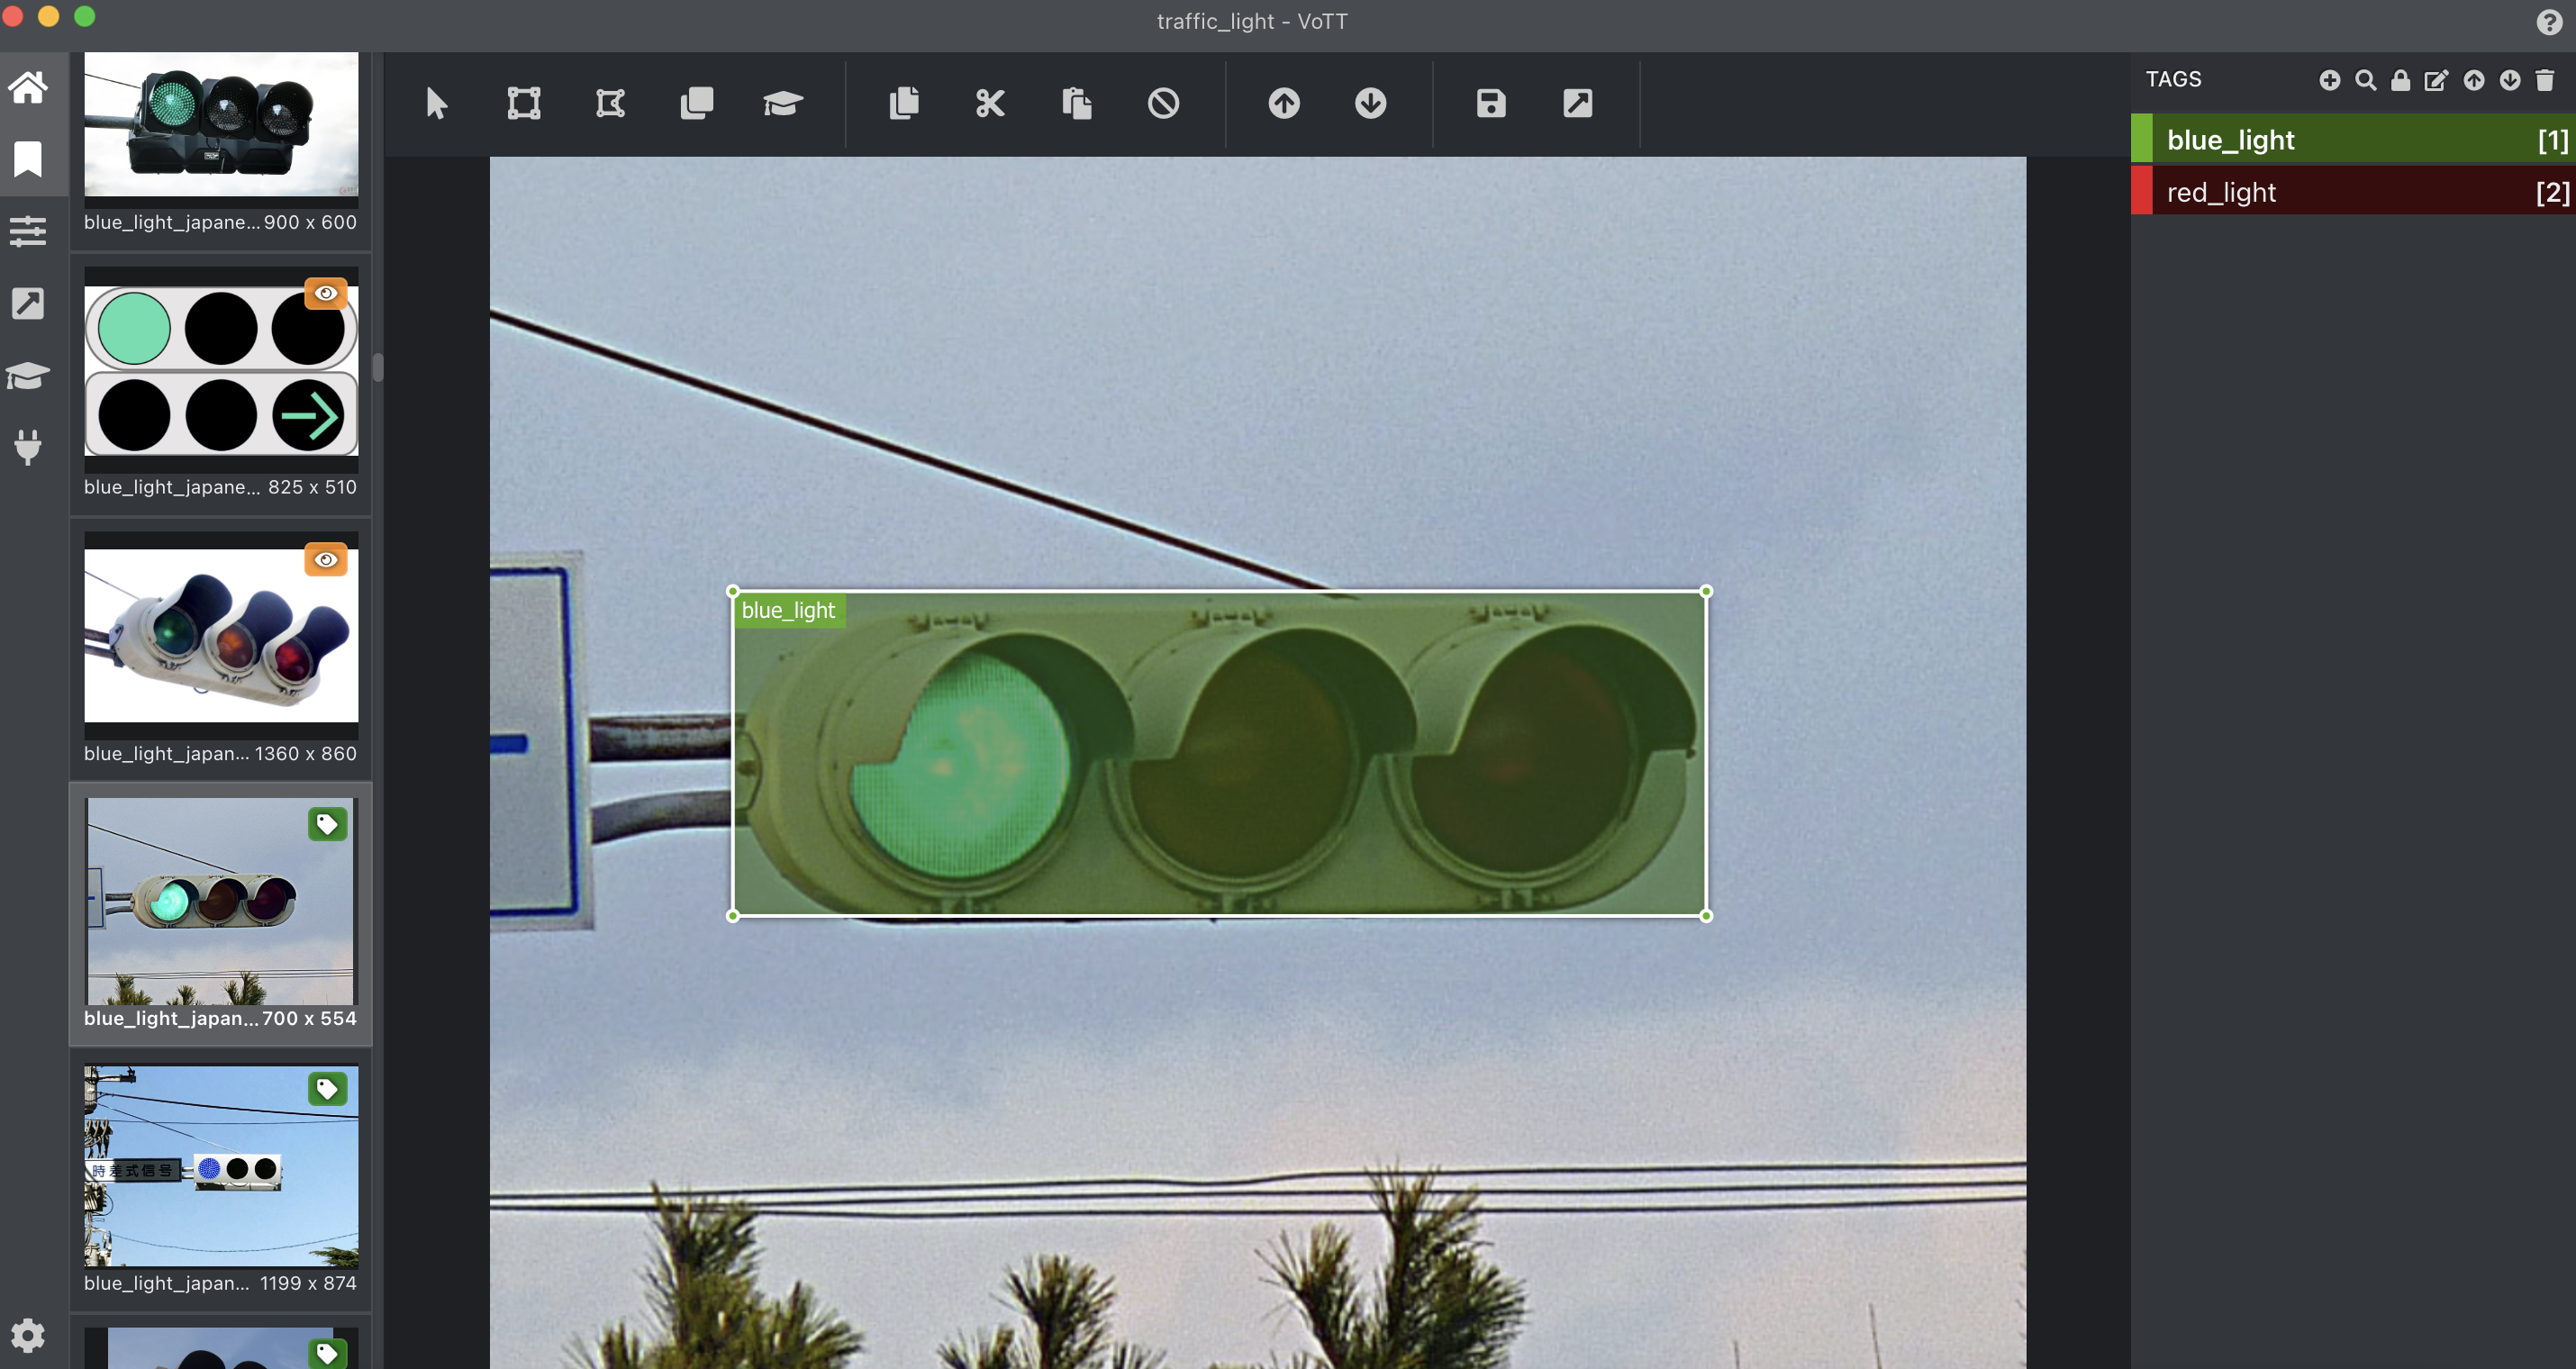

アノテーションが完了したデータのサンプルがこちらになります。<br>
https://drive.google.com/drive/folders/1JGub5lqRZoC79Yoyzx2Ex1XGPeVoUrB3?usp=drive_link<br>
<br>
このデータを、例によってPascal VOC形式からYOLO形式に変換します。

In [ ]:
def convert_pascal_voc_to_yolo(pascal_voc_dir, yolo_dir, class_names):
    # YOLO形式のラベルファイルとイメージファイルを格納するディレクトリを作成
    os.makedirs(os.path.join(yolo_dir, "labels"), exist_ok=True)
    os.makedirs(os.path.join(yolo_dir, "images"), exist_ok=True)

    # クラス名とIDの対応関係を定義
    class_id_map = {class_name: i for i, class_name in enumerate(class_names)}

    # PascalVOC形式のアノテーションファイルを読み込んで、YOLO形式に変換
    for xml_file in os.listdir(os.path.join(pascal_voc_dir, "Annotations")):
        tree = ET.parse(os.path.join(pascal_voc_dir, "Annotations", xml_file))
        root = tree.getroot()

        # 画像のサイズを取得
        img_width = int(root.find("size").find("width").text)
        img_height = int(root.find("size").find("height").text)

        # YOLO形式のラベルファイルを作成
        yolo_label_file = os.path.join(yolo_dir, "labels", os.path.splitext(xml_file)[0] + ".txt")
        with open(yolo_label_file, "w") as f:
            for obj in root.iter("object"):
                class_name = obj.find("name").text
                class_id = class_id_map[class_name]

                # バウンディングボックスの座標を取得し、整数に変換
                xmin = int(float(obj.find("bndbox").find("xmin").text))
                ymin = int(float(obj.find("bndbox").find("ymin").text))
                xmax = int(float(obj.find("bndbox").find("xmax").text))
                ymax = int(float(obj.find("bndbox").find("ymax").text))

                x_center = (xmin + xmax) / 2 / img_width
                y_center = (ymin + ymax) / 2 / img_height
                width = (xmax - xmin) / img_width
                height = (ymax - ymin) / img_height

                # YOLO形式のラベルをファイルに書き込み
                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

        # 対応する画像ファイルをコピー
        img_file = os.path.join(pascal_voc_dir, "JPEGImages", os.path.splitext(xml_file)[0] + ".jpg")
        if os.path.isfile(img_file):
            img = Image.open(img_file)
            img.save(os.path.join(yolo_dir, "images", os.path.splitext(xml_file)[0] + ".jpg"))
        else:
            print(f"Warning: Image file not found for {xml_file}")

    print("変換が完了しました。")

    # data.yamlファイルを作成
    data_yaml = f"""
    train: {yolo_dir}/images
    val: {yolo_dir}/images
    nc: {len(class_names)}
    names: {class_names}
    """
    with open(os.path.join(yolo_dir, "data.yaml"), "w") as f:
        f.write(data_yaml)

In [ ]:
#変換に必要な情報の指定
pascal_voc_dir = "/content/drive/MyDrive/画像/traffic_light-PascalVOC-export"  #PascalVOC形式のデータが格納されているディレクトリ
yolo_dir = "/content/annotation"  #YOLO形式のデータを格納するディレクトリ
class_names = ["blue_light", "red_light"]  #クラス名のリスト

#変換の実行
convert_pascal_voc_to_yolo(pascal_voc_dir, yolo_dir, class_names)

変換が完了しました。


## <font color=#0e89b2>ステップ3：モデルの構築・学習・予測</font>

準備したアノテーションデータを使って、YOLOv8をファインチューニングします。

In [ ]:
#モデルの読み込み
model = YOLO("yolov8m.pt")

#ファインチューニングの実行
model.train(data="/content/annotation/data.yaml",
            epochs=20, #学習回数
            degrees=10, #データの水増し処理（±10度の範囲内で回転）
            translate=0.5 #データの水増し処理（
            )

Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/annotation/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train7, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, s

train: Scanning /content/annotation/labels... 245 images, 0 backgrounds, 0 corrupt: 100%|██████████| 245/245 [00:00<00:00, 1738.15it/s]

train: New cache created: /content/annotation/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
val: Scanning /content/annotation/labels.cache... 245 images, 0 backgrounds, 0 corrupt: 100%|██████████| 245/245 [00:00<?, ?it/s]


Plotting labels to runs/detect/train7/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train7
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        245        266      0.496      0.915      0.578      0.367



20 epochs completed in 0.082 hours.
Optimizer stripped from runs/detect/train7/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train7/weights/best.pt, 52.0MB

Validating runs/detect/train7/weights/best.pt...
Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25840918 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:07<00:00,  1.12it/s]


                   all        245        266      0.496      0.915      0.578      0.367
            blue_light        245        123      0.477      0.927      0.542      0.346
             red_light        245        143      0.514      0.903      0.615      0.388
Speed: 0.4ms preprocess, 8.3ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to runs/detect/train7


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f20f7f5cf70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

ファインチューニングが完了しました。<br>
新規の画像を使って予測を実行してみます。

In [ ]:
def predict_image(image_path):
    #物体検出を実行
    result = model.predict(image_path, save=True)

    # 検出結果の画像を取得
    result_image = result[0].plot()

    # 検出結果の画像をcv2_imshow()で表示
    cv2_imshow(result_image)


image 1/1 /content/test.jpeg: 448x640 2 blue_lights, 1 red_light, 27.0ms
Speed: 1.7ms preprocess, 27.0ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/train72


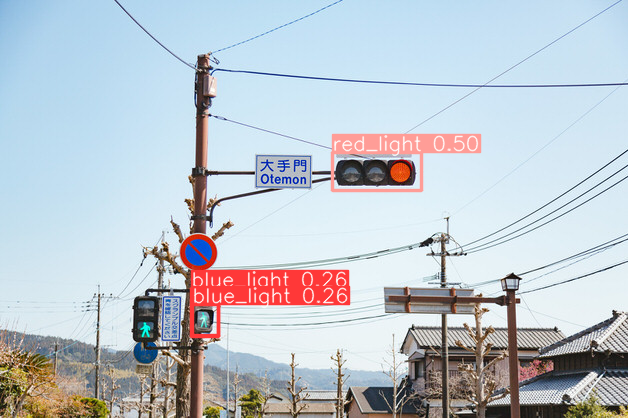

In [ ]:
predict_image("/content/traffic_light1.jpg")


image 1/1 /content/test2.jpeg: 448x640 1 red_light, 26.3ms
Speed: 1.3ms preprocess, 26.3ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/train73


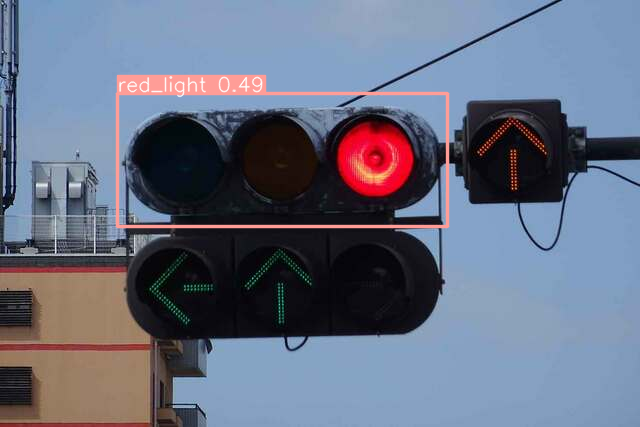

In [ ]:
predict_image("/content/traffic_light2.jpg")


image 1/1 /content/test3.jpeg: 544x640 1 red_light, 35.0ms
Speed: 4.1ms preprocess, 35.0ms inference, 1.5ms postprocess per image at shape (1, 3, 544, 640)
Results saved to runs/detect/train74


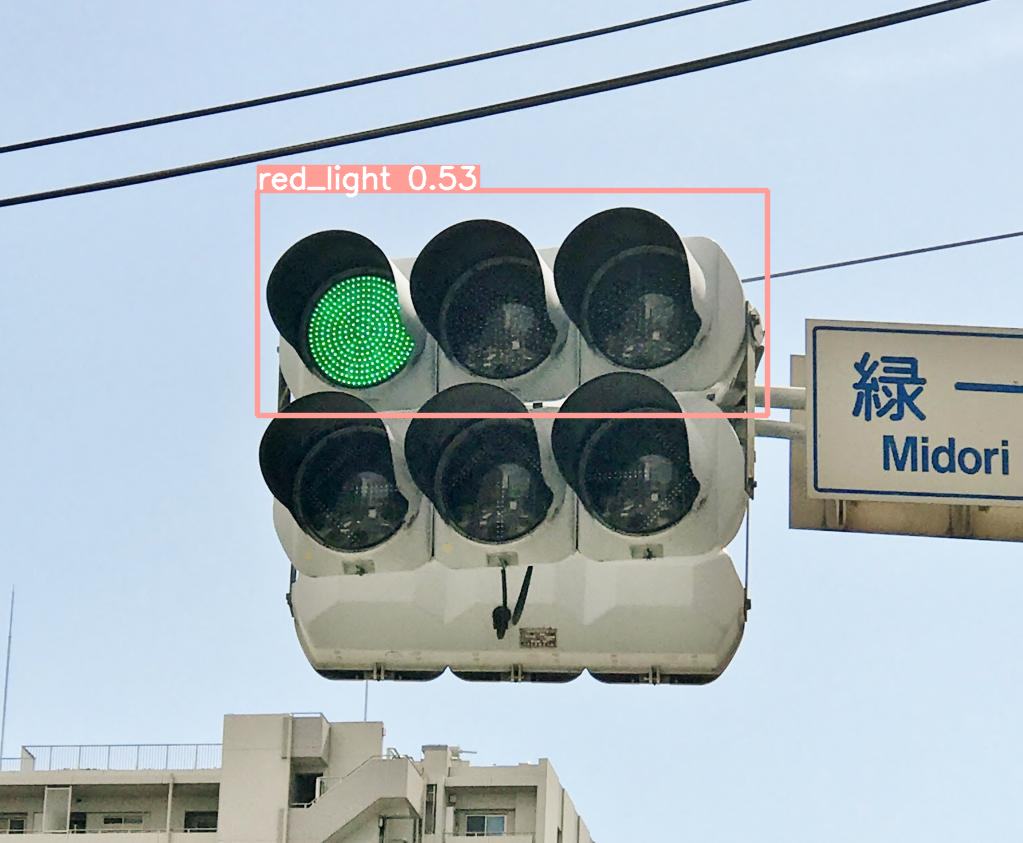

In [ ]:
predict_image("/content/traffic_light3.jpg")

一般的に、YOLOを赤信号と青信号のような2クラスでファインチューニングする場合、<br>
これくらいのデータ件数が必要です。

* 最低限必要なデータ件数: クラスごとに300〜500件 (合計600〜1000件)
* 理想的なデータ件数: クラスごとに1000〜2000件 (合計2000〜4000件)


今回はデータ件数が合計200-300程度と少ないですが、データ数を増やしていけばさらに精度が上がっていくはずです。